# Pagoda2.1 Multiome Workflow (RNA + ATAC)

A 10x
[multiome](https://www.10xgenomics.com/datasets/pbmc-from-a-healthy-donor-granulocytes-removed-through-cell-sorting-3-k-1-standard-2-0-0)
sample (PBMC, granulocyte-sorted 3k) measures each cell by both gene
expression (RNA) and chromatin accessibility (ATAC peaks). Each modality
is a **facet**: RNA uses the `plain` view, ATAC uses `tfidf` reduced by
**LSI** (TF-IDF → SVD, dropping the depth-correlated first component).
The two are integrated with **WNN**, exactly as for CITE-seq — only the
per-facet reductions differ. The 10x file is in a local folder named
`data`.

## Import

In [ ]:
p2 <- pagoda2::Pagoda2$from10xH5("data/pbmc_granulocyte_sorted_3k_filtered_feature_bc_matrix.h5", verbose = FALSE)
sapply(p2$listFacets(), function(f) p2$getFacet(f)$modelType)   # facet -> view model

    RNA    ATAC 
"plain" "tfidf" 

## QC

In [ ]:
p2$runQC(verbose = FALSE)

## Per-facet reductions: RNA PCA + ATAC LSI

RNA → PCA on overdispersed genes; ATAC → LSI on its TF-IDF view. For a
quick tutorial we run LSI on the most-accessible peaks; drop the
`genes =` subset for a full analysis.

In [ ]:
p2$runVariance(verbose = FALSE)
p2$runReduction(nPcs = 30, verbose = FALSE)
top.peaks <- names(sort(Matrix::colSums(p2$getFacet("ATAC")$rawCounts), decreasing = TRUE))[1:20000]
p2$runReduction(facet = "ATAC", method = "lsi", genes = top.peaks, nPcs = 30, verbose = FALSE)
names(p2$reductions)

[1] "PCA"      "ATAC:LSI"

## WNN integration and clustering

In [ ]:
p2$runGraph(method = "wnn", facets = c("RNA", "ATAC"), verbose = FALSE)
p2$runClustering(graph = "WNN", name = "wnn_leiden")

## What each modality resolves

Embed each facet’s reduction and the joint WNN reduction, colored by the
**same** joint clusters:

In [ ]:
p2$runEmbedding(reduction = "PCA", name = "umap", verbose = FALSE)        # RNA alone
p2$runEmbedding(reduction = "ATAC:LSI", name = "umap", verbose = FALSE)   # ATAC alone
p2$runEmbedding(reduction = "WNN", name = "umap", verbose = FALSE)        # joint

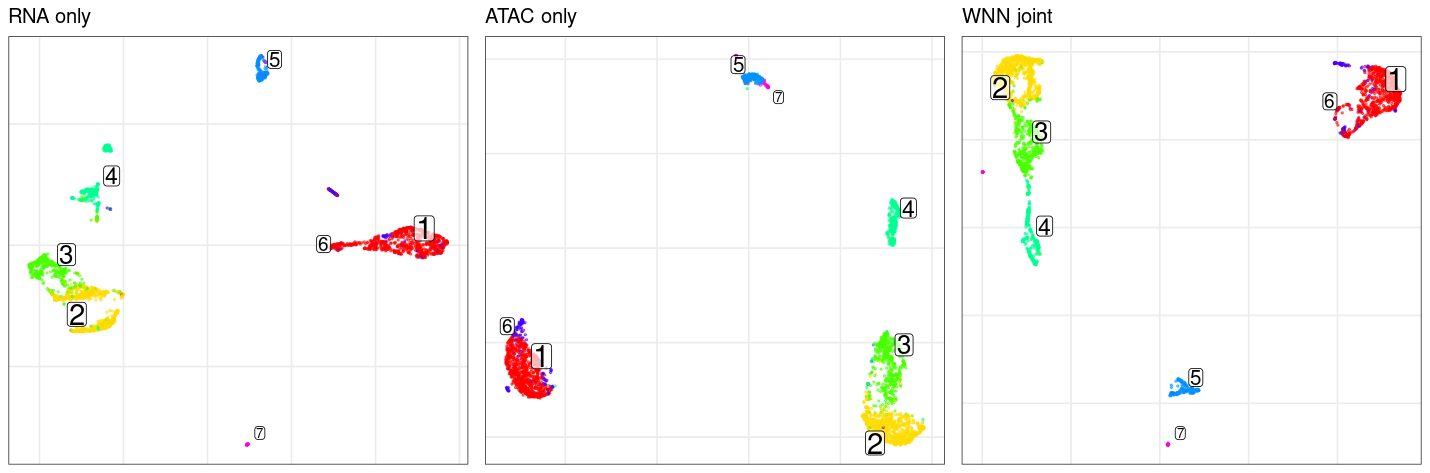

In [ ]:
g_rna <- p2$plotEmbedding(reduction = "PCA", embedding = "umap", grouping = "wnn_leiden", mark.groups = TRUE, size = 0.4, alpha = 0.5, title = "RNA only")
g_atac <- p2$plotEmbedding(reduction = "ATAC:LSI", embedding = "umap", grouping = "wnn_leiden", mark.groups = TRUE, size = 0.4, alpha = 0.5, title = "ATAC only")
g_wnn <- p2$plotEmbedding(reduction = "WNN", embedding = "umap", grouping = "wnn_leiden", mark.groups = TRUE, size = 0.4, alpha = 0.5, title = "WNN joint")
cowplot::plot_grid(g_rna, g_atac, g_wnn, nrow = 1)

The per-cell ATAC weight shows where chromatin accessibility drives the
joint structure:

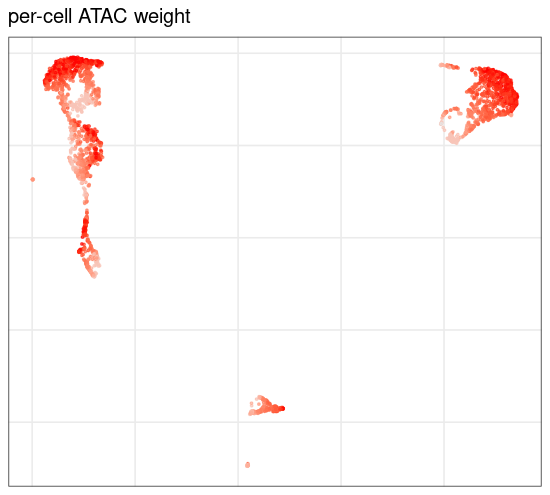

In [ ]:
p2$plotEmbedding(reduction = "WNN", embedding = "umap",
                 colors = stats::setNames(p2$cellMeta$wnn_weight_ATAC, rownames(p2$cellMeta)),
                 size = 0.5, alpha = 0.7, title = "per-cell ATAC weight")

## Markers

Markers are computed on the RNA facet (the interpretable modality); the
joint clusters are annotated from these.

In [ ]:
p2$runMarkers(grouping = "wnn_leiden", name = "wnn_markers", verbose = FALSE)

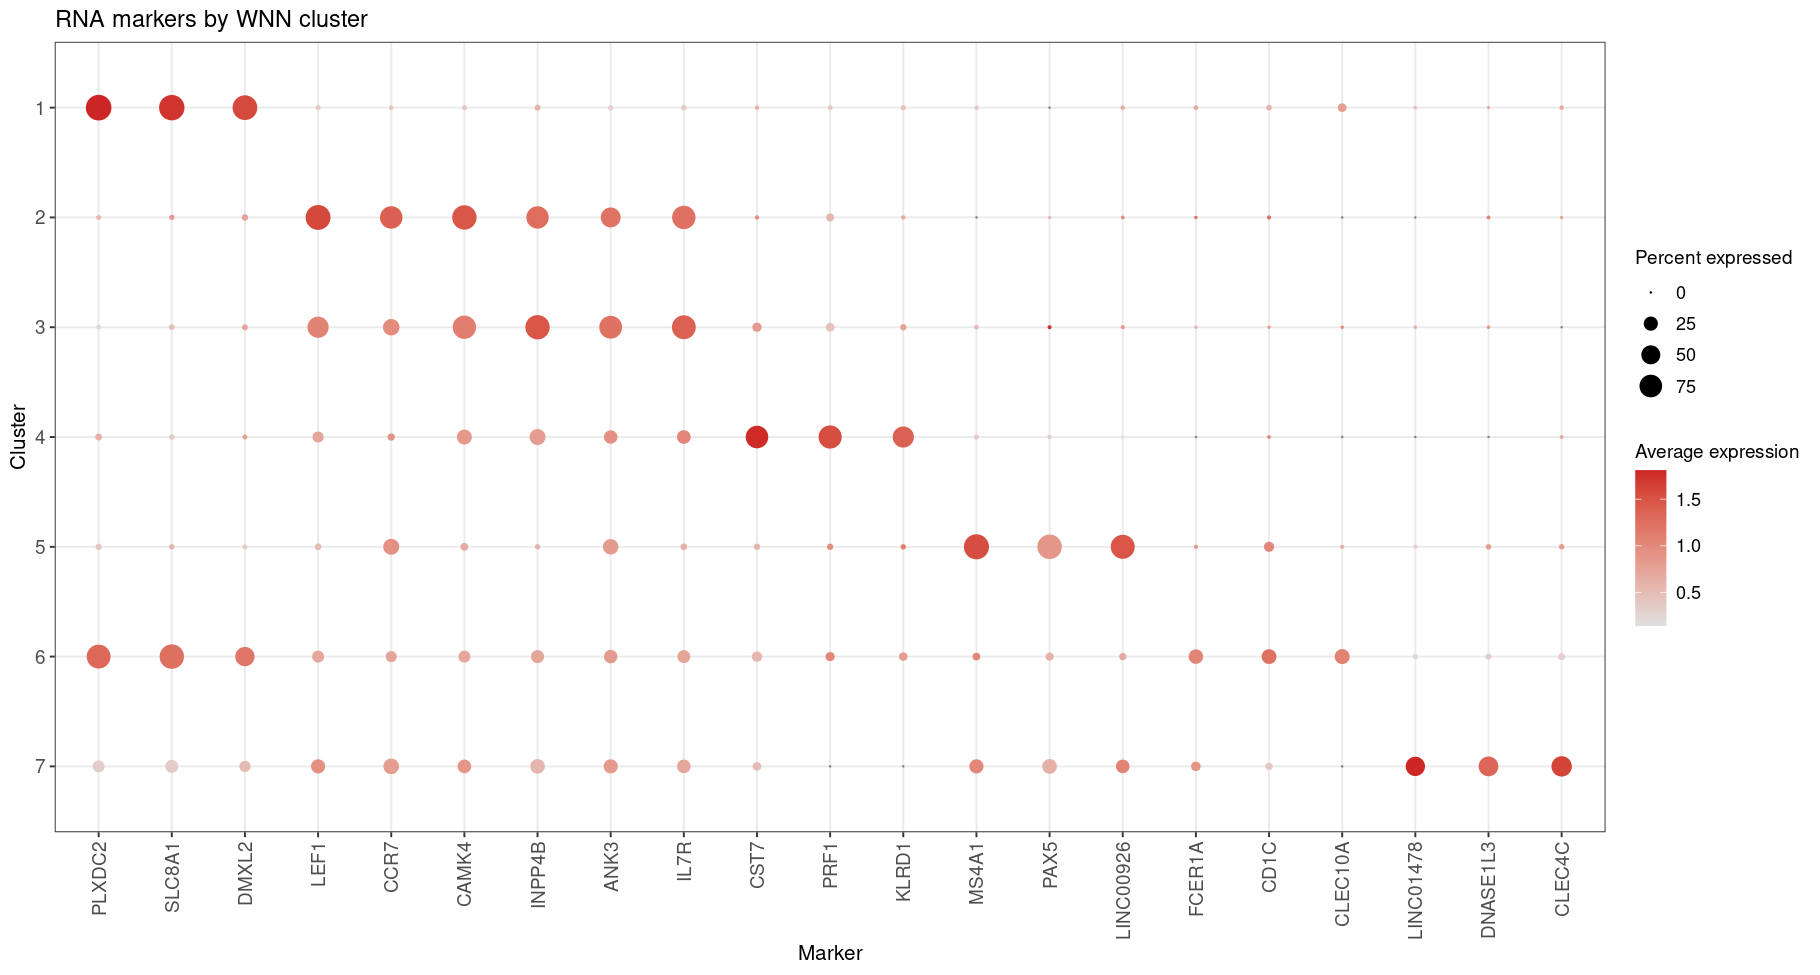

In [ ]:
p2$plotMarkerDotPlot(markers = "wnn_markers", n.genes.per.group = 3, selection = "balanced",
                     order.groups = TRUE, dot.scale = 6) +
  ggplot2::labs(title = "RNA markers by WNN cluster") +
  ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 90, hjust = 1, vjust = 0.5))

Canonical lineage genes on the joint embedding confirm the clusters:

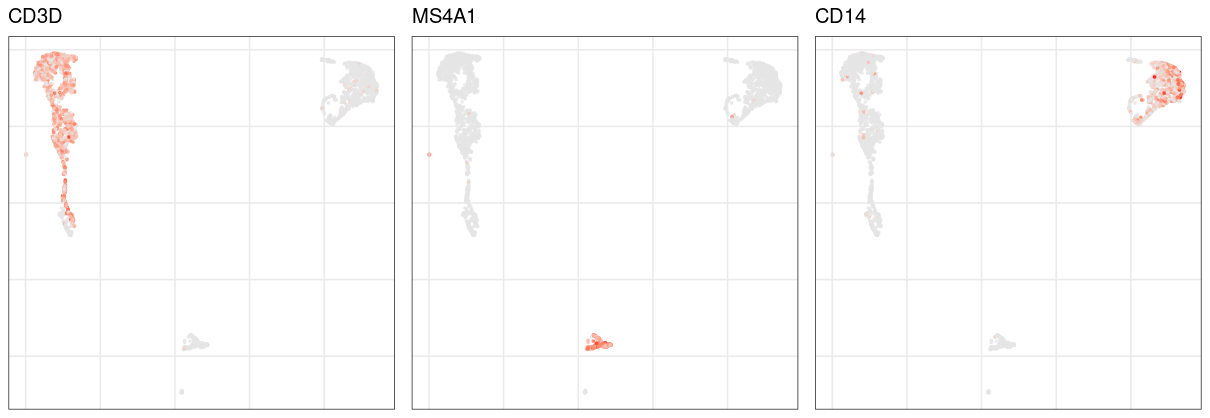

In [ ]:
genes <- intersect(c("CD3D", "MS4A1", "CD14"), colnames(p2$getRawCounts()))
plots <- lapply(genes, function(g)
  p2$plotEmbedding(reduction = "WNN", embedding = "umap", gene = g, size = 0.5, alpha = 0.7, title = g))
cowplot::plot_grid(plotlist = plots, nrow = 1)

## Next steps

Annotate the WNN clusters from the RNA markers. Reduction-level
integration is also available
(`p2$runReduction(facets = c("RNA","ATAC"), method = "cca")`), and a
disk-backed `backend = "lstar"` facet keeps large peak matrices out of
memory. See the [single-dataset](pagoda2.1-single-dataset.ipynb) and
[CITE-seq](pagoda2.1-citeseq.ipynb) notebooks for the other modalities.